In [ ]:
# ============================================
# 1) Imports & device setup
# ============================================

import numpy as np                    # For numerical operations
import pandas as pd                   # For CSV loading/handling
import torch                          # Core PyTorch
import torch.nn as nn                 # Neural network layers
import torch.optim as optim           # Optimizers (Adam, etc.)
from torch.utils.data import Dataset, DataLoader  # Dataset / batching utilities

import matplotlib.pyplot as plt       # For plotting
from sklearn.model_selection import train_test_split  # For train/val split

# Select CPU or GPU depending on what Colab has available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


In [55]:
# ============================================
# 2) Load CSV data and prepare X (geometry) and Y (S11)
# ============================================

# ---- USER: update this path to where your CSV is in Colab ----
csv_path = "//content/Full_1000Data.csv"  # e.g., upload with left-side "Files" panel

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_path)

print("Full data shape (rows, cols):", df.shape)
print(df.head())  # Show first few rows to verify structure

# Convert entire table to a NumPy array of float32
data = df.values.astype(np.float32)

# Geometry: first 100 columns = 10x10 patch flattened (0/1 bits)
input_dim = 100
X = data[:, :input_dim]  # Shape: [N, 100]

# Targets: next 61 columns = S11(dB) from 1 GHz to 6 GHz
seq_len = 61
Y = data[:, input_dim:input_dim + seq_len]  # Shape: [N, 61]

print("Geometry X shape:", X.shape)
print("S11 Y shape:", Y.shape)

# Normalize Y (S11 dB) across the dataset for better training
# We store mean/std to convert back later for plotting
y_mean = Y.mean(axis=0, keepdims=True)              # [1, 61]
y_std = Y.std(axis=0, keepdims=True) + 1e-8         # [1, 61]
Y_norm = (Y - y_mean) / y_std                       # normalized target

print("Example Y mean (first 5 freqs):", y_mean[0, :5])
print("Example Y std  (first 5 freqs):", y_std[0, :5])


Full data shape (rows, cols): (999, 161)
   1  1.1  0  0.1  0.2  1.2  0.3  1.3  0.4  0.5  ...  -6.88145609  \
0  0    1  1    1    1    0    0    0    1    0  ...    -0.793854   
1  0    0  0    0    0    1    0    0    1    1  ...    -0.184944   
2  0    1  0    1    0    0    0    1    1    1  ...    -1.570946   
3  0    1  1    1    0    0    0    1    0    0  ...    -3.807666   
4  1    1  0    1    0    0    0    0    0    1  ...    -8.271885   

   -6.037613644  -1.655797691  -1.035731954  -0.773821279  -0.722734269  \
0     -0.777272     -0.845772     -1.005418     -1.285064     -1.790792   
1     -0.194142     -0.199851     -0.214507     -0.228006     -0.238948   
2     -2.260451     -2.891146     -2.499796     -1.326414     -0.843298   
3     -1.604002     -0.910491     -0.633313     -0.531608     -0.480985   
4     -4.557592     -2.920305     -2.171188     -1.790006     -1.653269   

   -2.044756588  -0.908232993  -1.224834037  -0.613858326  
0     -2.244044     -2.689421    

In [56]:
# ============================================
# 3) PyTorch Dataset and DataLoader
# ============================================

class PatchAntennaDataset(Dataset):
    """
    Dataset for:
      - X: 10x10 geometry flattened to 100 bits
      - Y: 61-point S11(dB) (normalized)
    """
    def __init__(self, X, Y):
        # Convert NumPy arrays to torch tensors
        self.X = torch.from_numpy(X)      # [N, 100]
        self.Y = torch.from_numpy(Y)      # [N, 61]

    def __len__(self):
        # Number of samples in dataset
        return self.X.shape[0]

    def __getitem__(self, idx):
        # Return a single (input, target) pair
        return self.X[idx], self.Y[idx]

# Split into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y_norm, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Val size  :", X_val.shape[0])

# Create dataset objects
train_dataset = PatchAntennaDataset(X_train, Y_train)
val_dataset   = PatchAntennaDataset(X_val, Y_val)

# DataLoader handles batching + shuffling
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))


Train size: 799
Val size  : 200
Train batches: 13
Val batches  : 4


In [57]:
# ============================================
# A) Augmentation hyperparameters (for X only)
# ============================================

# Probability that any given bit will flip 0↔1
aug_bitflip_prob = 0.02   # 2% is a good starting point

# Probability of applying a block mask to a given sample
aug_block_mask_prob = 0.3  # 30% of samples get a masked block

# Maximum width of the contiguous block to zero (in bits)
aug_block_max_width = 10   # up to 10 bits in a row


In [58]:
# ============================================
# 4) Graph utilities: 10x10 grid adjacency
# ============================================

def build_grid_adjacency(h=10, w=10):
    """
    Build adjacency matrix for a 2D grid graph of size h x w.
    Each node connects to its 4-neighbors (up, down, left, right).
    """
    N = h * w
    A = np.zeros((N, N), dtype=np.float32)

    def idx(r, c):
        # Map 2D grid coordinate (r, c) to 1D index in [0, N-1]
        return r * w + c

    for r in range(h):
        for c in range(w):
            i = idx(r, c)
            if r > 0:     A[i, idx(r-1, c)] = 1.0  # up
            if r < h-1:   A[i, idx(r+1, c)] = 1.0  # down
            if c > 0:     A[i, idx(r, c-1)] = 1.0  # left
            if c < w-1:   A[i, idx(r, c+1)] = 1.0  # right

    # Add self-connections so each node sees itself
    A += np.eye(N, dtype=np.float32)

    # Compute normalized adjacency: A_norm = D^{-1/2} A D^{-1/2}
    D = np.sum(A, axis=1)                         # Degree of each node
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-8)) # Avoid divide-by-zero
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt          # Symmetric norm

    return torch.from_numpy(A_norm)  # Return as torch tensor

# Precompute adjacency once and move to device
A_norm = build_grid_adjacency(h=10, w=10).to(device)  # [100, 100]
print("Adjacency shape:", A_norm.shape)


Adjacency shape: torch.Size([100, 100])


In [59]:
# ============================================
# 5) Simple GCN layer and GNN-Transformer encoder
# ============================================

class GCNLayer(nn.Module):
    """
    Basic Graph Convolution Network (GCN) layer:
      H_new = sigma(A_norm @ H @ W)
    where:
      - A_norm is precomputed normalized adjacency matrix
      - H is node feature matrix [B, N, F_in]
      - W is learnable matrix [F_in, F_out]
    """
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)  # Linear transformation

    def forward(self, H, A_norm):
        # H: [B, N, F_in]
        # A_norm: [N, N]
        # First apply linear transformation
        H_lin = self.lin(H)  # [B, N, F_out]
        # Then message passing with A_norm
        # We compute: A_norm @ H_lin for each batch separately
        H_out = torch.matmul(A_norm, H_lin)  # [B, N, F_out]
        return torch.relu(H_out)             # Apply ReLU nonlinearity


class GNNTransformerEncoder(nn.Module):
    """
    Encode a 10x10 patch (100 bits) using:
      - GCN layers on a 10x10 grid graph
      - Transformer encoder on node sequence
      - Global pooling to single latent vector
    """
    def __init__(self, node_in_dim=1, d_model=128, num_gcn_layers=2, num_tf_layers=2, num_heads=4):
        super().__init__()

        self.d_model = d_model
        self.node_in_dim = node_in_dim
        self.num_nodes = 100  # 10x10 fixed

        # Project scalar bit (0/1) to d_model-dimensional embedding
        self.input_proj = nn.Linear(node_in_dim, d_model)

        # GCN layers
        self.gcn_layers = nn.ModuleList([
            GCNLayer(d_model, d_model) for _ in range(num_gcn_layers)
        ])

        # Positional encoding for the 100 nodes (learnable)
        self.pos_encoding = nn.Parameter(torch.randn(1, self.num_nodes, d_model))

        # Transformer encoder: batch_first=True => input [B, N, d_model]
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=4*d_model,
            batch_first=True
        )
        self.tf_encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_tf_layers
        )

        # Final projection to a single latent vector (pool)
        self.pool = nn.AdaptiveAvgPool1d(1)  # average over nodes

    def forward(self, x_bits, A_norm):
        """
        x_bits: [B, 100] with 0/1 bits
        A_norm: [100, 100] adjacency (same for all samples)
        """
        B = x_bits.size(0)

        # Reshape from [B, 100] to [B, 100, 1] (node features)
        H = x_bits.view(B, self.num_nodes, self.node_in_dim)

        # Project 1-dim bits to d_model-dim embeddings
        H = self.input_proj(H)  # [B, 100, d_model]

        # Apply several GCN layers
        for gcn in self.gcn_layers:
            H = gcn(H, A_norm)  # [B, 100, d_model]

        # Add learnable positional encodings
        H = H + self.pos_encoding  # [B, 100, d_model]

        # Transformer encoder over node sequence
        H_enc = self.tf_encoder(H)  # [B, 100, d_model]

        # Pool over nodes to get a single latent vector per sample
        # pool expects [B, d_model, N], so transpose first
        H_enc_t = H_enc.transpose(1, 2)         # [B, d_model, 100]
        pooled = self.pool(H_enc_t).squeeze(-1) # [B, d_model]

        return pooled  # [B, d_model]


In [60]:
# ============================================
# 6) FEDformer-style Fourier decoder block
# ============================================

class FedformerBlock(nn.Module):
    """
    Simplified FEDformer-style block:
      - Apply FFT along sequence length (frequency axis)
      - Inverse FFT (spectral mixing)
      - Residual connection + LayerNorm
      - Feed-forward network + residual
    This captures global interactions in frequency domain.
    """
    def __init__(self, d_model, dim_feedforward=256):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Position-wise feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )

    def forward(self, x):
        """
        x: [B, L, d_model]
        """
        # 1) Fourier mixing (no extra parameters, just FFT/iFFT)
        # Move to complex via FFT along sequence dimension
        x_fft = torch.fft.rfft(x, dim=1)       # [B, L_fft, d_model] complex
        x_ifft = torch.fft.irfft(x_fft, n=x.size(1), dim=1)  # back to [B, L, d_model]

        # Residual connection and normalization
        x = self.norm1(x + x_ifft)

        # 2) Feed-forward with residual
        x_ffn = self.ffn(x)
        x = self.norm2(x + x_ffn)

        return x  # [B, L, d_model]


class FedformerDecoder(nn.Module):
    """
    Decoder that maps a latent vector [B, d_model] to a sequence [B, L, 1]
    using multiple FedformerBlocks.
    """
    def __init__(self, d_model=128, seq_len=61, num_layers=3):
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len

        # Project latent vector to an initial sequence of d_model tokens
        self.init_proj = nn.Linear(d_model, d_model)

        # Positional encoding for frequency axis (learnable)
        self.pos_encoding = nn.Parameter(torch.randn(1, seq_len, d_model))

        # Stack of FedformerBlocks
        self.layers = nn.ModuleList([
            FedformerBlock(d_model=d_model, dim_feedforward=4*d_model)
            for _ in range(num_layers)
        ])

        # Final projection to scalar S11 per frequency
        self.out_proj = nn.Linear(d_model, 1)  # -> [B, L, 1]

    def forward(self, z):
        """
        z: [B, d_model] latent vector from encoder
        """
        B = z.size(0)

        # Create an initial [B, L, d_model] by repeating transformed latent
        z_init = self.init_proj(z)             # [B, d_model]
        z_seq = z_init.unsqueeze(1).repeat(1, self.seq_len, 1)  # [B, L, d_model]

        # Add frequency positional encoding
        x = z_seq + self.pos_encoding  # [B, L, d_model]

        # Pass through FedformerBlocks
        for layer in self.layers:
            x = layer(x)  # [B, L, d_model]

        # Project to 1D S11 per frequency
        out = self.out_proj(x).squeeze(-1)  # [B, L]

        return out  # normalized S11 predictions


In [61]:
# ============================================
# 7) Full model: GNN-Transformer encoder + FEDformer decoder
# ============================================

class PatchGNNFedformer(nn.Module):
    """
    End-to-end model:
      Input:  [B, 100] (10x10 patch bits)
      Output: [B, 61]  (normalized S11 dB)
    """
    def __init__(self, d_model=128, seq_len=61):
        super().__init__()
        self.encoder = GNNTransformerEncoder(
            node_in_dim=1,
            d_model=d_model,
            num_gcn_layers=2,
            num_tf_layers=2,
            num_heads=4
        )
        self.decoder = FedformerDecoder(
            d_model=d_model,
            seq_len=seq_len,
            num_layers=3
        )

    def forward(self, x_bits, A_norm):
        # Encode geometry to latent vector
        z = self.encoder(x_bits, A_norm)  # [B, d_model]
        # Decode latent vector to S11 sequence
        y = self.decoder(z)               # [B, seq_len]
        return y

# Instantiate model and move to device
d_model = 128
model = PatchGNNFedformer(d_model=d_model, seq_len=seq_len).to(device)
print(model)


PatchGNNFedformer(
  (encoder): GNNTransformerEncoder(
    (input_proj): Linear(in_features=1, out_features=128, bias=True)
    (gcn_layers): ModuleList(
      (0-1): 2 x GCNLayer(
        (lin): Linear(in_features=128, out_features=128, bias=True)
      )
    )
    (tf_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
   

In [62]:
# ============================================
# 8) Loss function and optimizer
# ============================================

# Mean squared error for regression on normalized S11
criterion = nn.MSELoss()

# AdamW optimizer works well for transformer-like models
learning_rate = 1e-3
weight_decay = 1e-4

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

print("Loss function:", criterion)
print("Optimizer:", optimizer)


Loss function: MSELoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [63]:
# ============================================
# B) Data augmentation for binary 0/1 inputs (geometry X)
# ============================================

def augment_batch_x_bits(x,
                         bitflip_prob=0.02,
                         block_mask_prob=0.3,
                         block_max_width=10):
    """
    Apply data augmentation to binary 0/1 geometry inputs (X), NOT to Y.

    x: [B, 100] tensor of 0/1 bits

    Augmentations:
      1) Random bit flips (0->1, 1->0) with small probability
      2) Random contiguous block masking (set some bits to 0)
    """
    # Work on a copy so we don't modify the original batch in-place
    x = x.clone()

    B, D = x.shape  # B = batch size, D = number of bits (100)

    # ------------------------------------------
    # 1) Random Bit Flips
    # ------------------------------------------
    if bitflip_prob > 0.0:
        # Create a flip mask using Bernoulli distribution:
        #   flip_mask[i,j] = 1 with prob=bitflip_prob => flip bit j in sample i
        flip_mask = (torch.rand(B, D, device=x.device) < bitflip_prob).int()

        # Flip bits: new_bit = 1 - old_bit where flip_mask=1
        # x * (1 - flip_mask)  keeps original bits where flip_mask=0
        # (1 - x) * flip_mask  gives flipped bits where flip_mask=1
        x = x * (1 - flip_mask) + (1 - x) * flip_mask

        # This ensures values remain exactly 0 or 1

    # ------------------------------------------
    # 2) Random Block Masking
    # ------------------------------------------
    if block_mask_prob > 0.0 and block_max_width > 0:
        # Make sure block width never exceeds the number of bits
        max_width = min(block_max_width, D)

        # Loop over each sample in the batch
        for b in range(B):
            # With probability block_mask_prob, apply a mask
            if torch.rand(1, device=x.device).item() < block_mask_prob:
                # Randomly choose a block width in [1, max_width]
                w = torch.randint(1, max_width + 1, (1,), device=x.device).item()

                # Choose a random start index so that start+width <= D
                start = torch.randint(0, D - w + 1, (1,), device=x.device).item()

                # Mask this contiguous block by setting bits to 0
                x[b, start:start + w] = 0

    return x


In [ ]:
# ============================================
# 9) Training loop with augmentation on X (training only)
# ============================================

num_epochs = 80   # adjust as needed

train_losses = []
val_losses   = []

for epoch in range(1, num_epochs + 1):
    # ---- Training phase ----
    model.train()
    running_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        # Move original batch to device
        x_batch = x_batch.to(device)  # [B, 100] 0/1 bits
        y_batch = y_batch.to(device)  # [B, 61] normalized S11

        # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
        # Apply augmentation ONLY in training, ONLY to X
        # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
        x_batch_aug = augment_batch_x_bits(
            x_batch,
            bitflip_prob=aug_bitflip_prob,
            block_mask_prob=aug_block_mask_prob,
            block_max_width=aug_block_max_width,
        )
        # Now x_batch_aug is the augmented geometry
        # and remains strictly 0/1 bits.
        # y_batch is unchanged.
        # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

        optimizer.zero_grad()

        # Forward pass with augmented geometry
        y_pred = model(x_batch_aug, A_norm)  # [B, 61]

        # Compute MSE between predicted and target normalized S11
        loss = criterion(y_pred, y_batch)

        # Backpropagate
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate total training loss (multiply by batch size to sum)
        running_train_loss += loss.item() * x_batch.size(0)

    # Compute average training loss for this epoch
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation phase (NO augmentation) ----
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # IMPORTANT: use the raw, non-augmented geometry for validation
            y_pred = model(x_batch, A_norm)

            loss = criterion(y_pred, y_batch)
            running_val_loss += loss.item() * x_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    # Print progress occasionally
    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")


Epoch   1/80 | Train Loss: 1.007610 | Val Loss: 0.977306
Epoch  10/80 | Train Loss: 1.012244 | Val Loss: 0.976004
Epoch  20/80 | Train Loss: 1.009193 | Val Loss: 0.974219


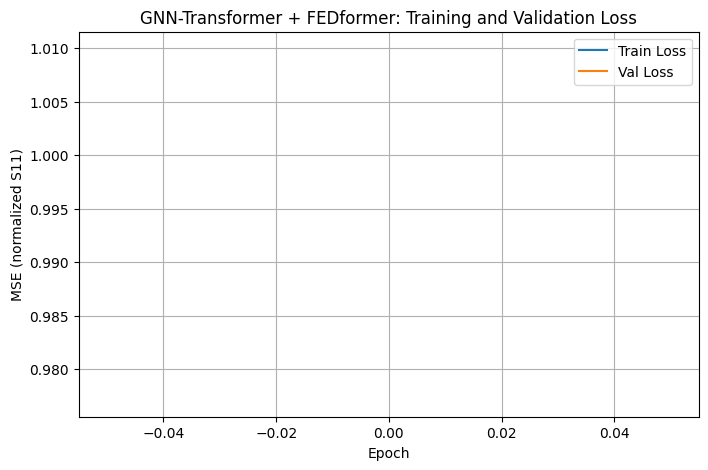

In [67]:
# ============================================
# 10) Plot training and validation loss
# ============================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (normalized S11)")
plt.title("GNN-Transformer + FEDformer: Training and Validation Loss")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# ============================================
# 11) Inspect predictions: true vs predicted S11 curves
# ============================================

model.eval()

# Take one batch from validation loader
x_val_batch, y_val_batch = next(iter(val_loader))
x_val_batch = x_val_batch.to(device)
y_val_batch = y_val_batch.to(device)

with torch.no_grad():
    y_pred_batch = model(x_val_batch, A_norm)  # [B, 61]

# Move to CPU and NumPy
y_true_norm = y_val_batch.cpu().numpy()  # normalized
y_pred_norm = y_pred_batch.cpu().numpy()

# De-normalize to actual dB values
y_true_db = y_true_norm * y_std + y_mean
y_pred_db = y_pred_norm * y_std + y_mean

# Frequency axis: 1 GHz to 6 GHz
freqs = np.linspace(1.0, 6.0, seq_len)

# Pick an example index in the batch to visualize
example_idx = 0  # change this to see more samples

true_curve = y_true_db[example_idx]  # [61]
pred_curve = y_pred_db[example_idx]  # [61]

plt.figure(figsize=(8, 5))
plt.plot(freqs, true_curve, label="True S11 (dB)")
plt.plot(freqs, pred_curve, "--", label="Predicted S11 (dB)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S11 (dB)")
plt.title("True vs Predicted S11 for One Geometry\n(GNN-Transformer + FEDformer)")
plt.grid(True)
plt.legend()
plt.show()

print("First 10 points (True vs Pred):")
for i in range(10):
    print(f"f={freqs[i]:.2f} GHz | True: {true_curve[i]:7.3f} dB | Pred: {pred_curve[i]:7.3f} dB")


In [ ]:
# ============================================
# 12) Compute overall MAE and RMSE on validation set
# ============================================

model.eval()
all_true = []
all_pred = []

with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(x_batch, A_norm)

        y_true_norm = y_batch.cpu().numpy()
        y_pred_norm = y_pred.cpu().numpy()

        y_true_db = y_true_norm * y_std + y_mean
        y_pred_db = y_pred_norm * y_std + y_mean

        all_true.append(y_true_db)
        all_pred.append(y_pred_db)

all_true = np.concatenate(all_true, axis=0)  # [N_val, 61]
all_pred = np.concatenate(all_pred, axis=0)  # [N_val, 61]

mae = np.mean(np.abs(all_true - all_pred))
rmse = np.sqrt(np.mean((all_true - all_pred)**2))

print(f"Validation MAE  (dB): {mae:.4f}")
print(f"Validation RMSE (dB): {rmse:.4f}")
